# Bitcoin Robustness and Temporal Stability

## Role
Apply training-defined regimes and balanced temporal segments to all ten models.

## Inputs
Frozen forecasts and derived robustness/stability CSVs.

## Outputs
Training-only thresholds, regime metrics, temporal metrics.

## Depends On
07 and 08.

## Authoritative Status
AUTHORITATIVE DOWNSTREAM ANALYSIS

## What This Notebook Does Not Do
It does not derive thresholds from test quantiles or fit models.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.bitcoin_pipeline import *
RUN_GENERATION = False
PROMOTE_TO_AUTHORITATIVE = False


In [2]:
# Load and validate the training-defined regime thresholds.
thresholds = pd.read_csv(ROOT / 'results' / 'bitcoin_regime_thresholds_training.csv')
assert thresholds.Source.eq('Training data only').all()

# Display the unchanged threshold table.
thresholds

,Threshold,Value,Source,Training_Start,Training_End
0,volatility_low_33,0.024310,Training data only,2012-01-01 00:00:00+00:00,2023-08-11 00:00:00+00:00
1,volatility_high_67,0.037532,Training data only,2012-01-01 00:00:00+00:00,2023-08-11 00:00:00+00:00
2,return_major_up_80,0.025095,Training data only,2012-01-01 00:00:00+00:00,2023-08-11 00:00:00+00:00
3,return_major_down_20,-0.018476,Training data only,2012-01-01 00:00:00+00:00,2023-08-11 00:00:00+00:00


In [3]:
# Load and validate the regime-conditional metrics.
robust = pd.read_csv(ROOT / 'results' / 'bitcoin_regime_robustness_training_defined.csv')
assert robust.Model.nunique() == 10

# Display the unchanged sample counts by regime.
robust.groupby('Regime').N.first()

Regime
High Volatility             81
Low Volatility             676
Major Downward Movement    174
Major Upward Movement      131
Name: N, dtype: int64

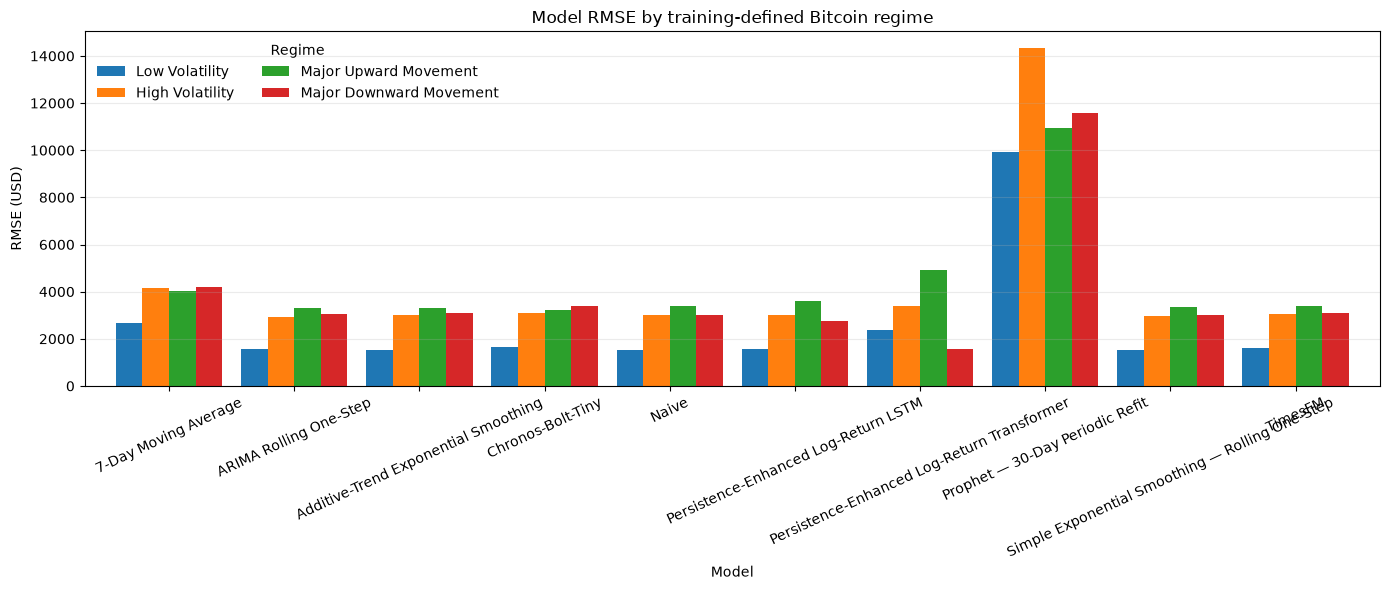

In [4]:
import matplotlib.pyplot as plt

# Pivot the frozen regime metrics for a grouped RMSE comparison.
regime_rmse = robust.pivot(index='Model', columns='Regime', values='RMSE')
ordered_regimes = ['Low Volatility', 'High Volatility', 'Major Upward Movement', 'Major Downward Movement']
ax = regime_rmse[ordered_regimes].plot(kind='bar', figsize=(14, 6), width=0.85)
ax.set(title='Model RMSE by training-defined Bitcoin regime', xlabel='Model', ylabel='RMSE (USD)')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Regime', frameon=False, ncol=2)
ax.figure.tight_layout()
plt.show()

In [5]:
# Load and validate the balanced temporal-segment metrics.
stability = pd.read_csv(ROOT / 'results' / 'bitcoin_temporal_stability.csv')
assert stability.Model.nunique() == 10

# Display the unchanged sample counts by segment.
stability.groupby('Segment').N.first()

Segment
Earlier    354
Later      353
Middle     354
Name: N, dtype: int64

These are Regime-Conditional Robustness and Temporal Stability diagnostics, not comprehensive robustness or broad generalisation claims.

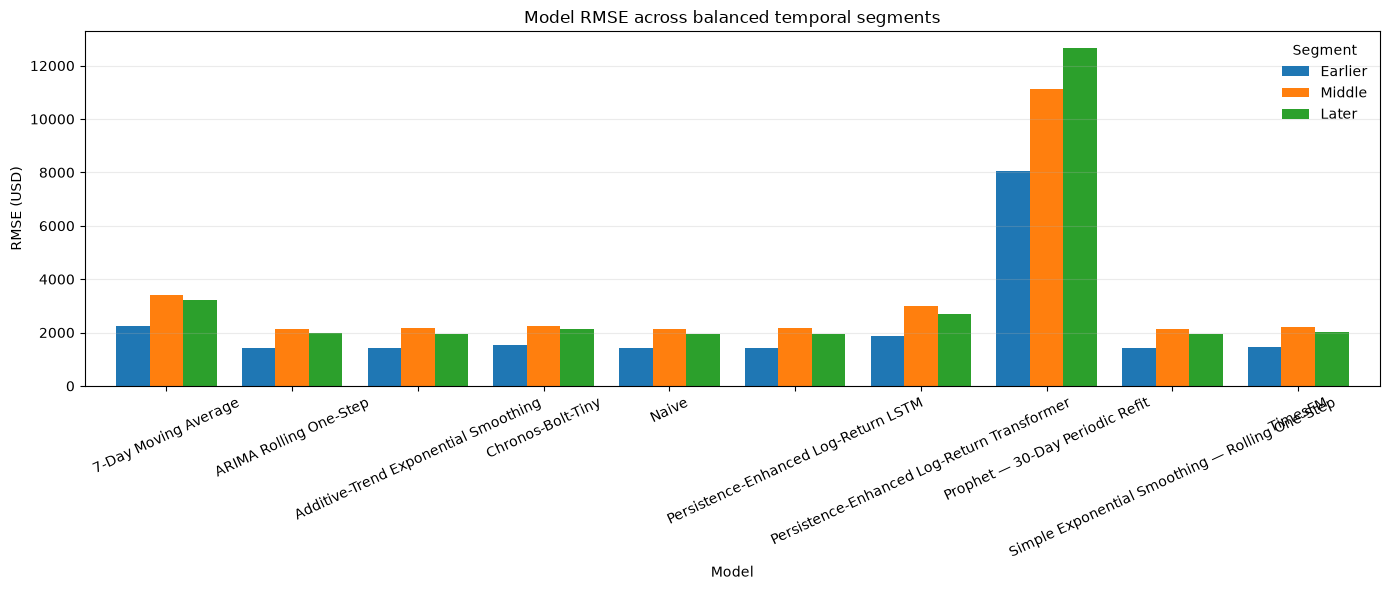

In [6]:
# Pivot the frozen temporal metrics for a grouped RMSE comparison.
segment_rmse = stability.pivot(index='Model', columns='Segment', values='RMSE')
ax = segment_rmse[['Earlier', 'Middle', 'Later']].plot(kind='bar', figsize=(14, 6), width=0.8)
ax.set(title='Model RMSE across balanced temporal segments', xlabel='Model', ylabel='RMSE (USD)')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Segment', frameon=False)
ax.figure.tight_layout()
plt.show()